<a href="https://colab.research.google.com/github/Jainam-gala16/Portfolio-Optimization-/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

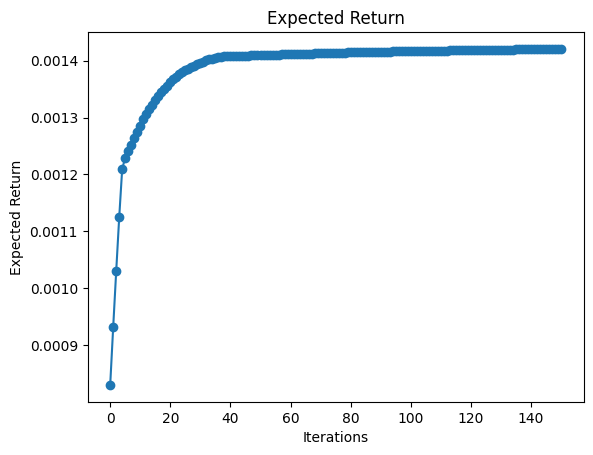

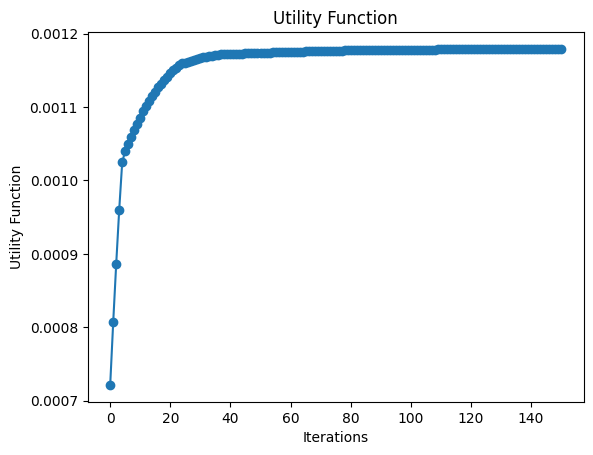

Optimal weights    Ticker       Weights
0    AAPL  0.000000e+00
1    MSFT  2.500000e-01
2    NVDA  0.000000e+00
3     JNJ  2.500000e-01
4     UNH  0.000000e+00
5     JPM  0.000000e+00
6       V  1.405126e-16
7      PG  2.500000e-01
8      KO  0.000000e+00
9     MCD  0.000000e+00
10    XOM  0.000000e+00
11    CAT  2.500000e-01

Expected return: 0.35799416771008646
Variance: 0.00024130913208914435
Utility: 0.0011793026445381834
Iterations: 151
Runtime: 0.5273470710000083
 
SLSQP Method
Optimal Weights:    Ticker  Weights
0    AAPL  0.00000
1    MSFT  0.18297
2    NVDA  0.00000
3     JNJ  0.17653
4     UNH  0.02491
5     JPM  0.01816
6       V  0.09492
7      PG  0.25000
8      KO  0.00000
9     MCD  0.00000
10    XOM  0.00250
11    CAT  0.25000

Expected Return
0.3485737084050741

Portfolio Variance
0.00022304977239510316

Utility
0.0011601792292123341


In [ ]:
# MVO Method
import yfinance as yf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time


# FOR USER: ONLY EDIT THE TICKERS, THE REST OF THE CODE WILL RUN
# 8 OR MORE STOCKS

tickers = ["AAPL", "MSFT", "NVDA", "JNJ", "UNH", "JPM",
           "V", "PG", "KO", "MCD", "XOM", "CAT"]

W_MAX = 0.25

np.random.seed(50)

raw = yf.download(tickers, period="5y", auto_adjust=True, progress=False)
prices = raw["Close"].dropna(how="any")

split = int(len(prices) * 0.8)
prices_train, prices_test = prices.iloc[:split], prices.iloc[split:]

TRADING_DAYS = 252
returns_train = prices_train.pct_change().dropna()
returns_test  = prices_test.pct_change().dropna()

mu    = returns_train.mean().values
Sigma = returns_train.cov().values

n = len(mu)

# Risk aversion
lam = 2


def project(v, w_max=W_MAX):
    """Euclidean Projection to fit constraints."""
    lo, hi = v.min() - 1.0, v.max()
    for _ in range(100):                      # 100 bissections -> précision ~1e-30
        tau = 0.5 * (lo + hi)
        if np.clip(v - tau, 0.0, w_max).sum() > 1.0:
            lo = tau
        else:
            hi = tau
    return np.clip(v - 0.5 * (lo + hi), 0.0, w_max)



def mvo_algorithm(tickers, learning_rate, risk_aversion, iterations, tol):
    raw = yf.download(tickers, period="5y", auto_adjust=True, progress=False)
    prices = raw["Close"].dropna(how="any")

  # Découpage entraînement / test (hors-échantillon)
    split = int(len(prices) * 0.8)
    prices_train, prices_test = prices.iloc[:split], prices.iloc[split:]

    TRADING_DAYS = 252
    returns_train = prices_train.pct_change().dropna()
    returns_test  = prices_test.pct_change().dropna()

    mu    = returns_train.mean().values          # rendements espérés annualisés
    Sigma = returns_train.cov().values        # covariance annualisée

    n = len(mu)


    weights = np.ones(n) / n

    return_prog = np.zeros(iterations)
    variance_prog = np.zeros(iterations)
    utility_prog = np.zeros(iterations)

    start = time.perf_counter()



    total_iterations = 0

    new_utility = -100

    time
    # Gradient Ascent
    for i in range(iterations):

        total_iterations += 1
        gradient = mu - risk_aversion * (Sigma @ weights)

        new_weights = project(weights + learning_rate * gradient)
        step  = np.linalg.norm(new_weights - weights)

        new_return = new_weights @ mu

        new_variance = risk_aversion / 2 * (new_weights @ Sigma @ new_weights)

        old_utility = new_utility
        new_utility = new_return - new_variance

        return_prog[i] = new_return
        variance_prog[i] = new_variance
        utility_prog[i] = new_utility

        if abs(step) < tol:
            break


        weights = new_weights
        # Long-only constraint
        weights = np.maximum(weights, 0)

        # Normalize
        weights /= weights.sum()

    return {"weights": weights, "return": weights @ mu, "utility": new_utility,
            "mu": mu, "sigma": Sigma,
            "return_prog": return_prog, "variance_prog": variance_prog, "utility_prog": utility_prog,
            "total_iterations": total_iterations,
            "runtime": time.perf_counter()- start}

ans = mvo_algorithm(tickers, 20, 2, 10000, 1e-10)

total_iterations = ans["total_iterations"]
return_prog = ans["return_prog"]
variance_prog = ans["variance_prog"]
weights = ans["weights"]
utility_prog = ans["utility_prog"]
utility = ans["utility"]
mu = ans["mu"]
Sigma = ans["sigma"]
runtime = ans["runtime"]

plt.plot(range(total_iterations), return_prog[0:total_iterations], marker='o')
plt.title('Expected Return')
plt.xlabel('Iterations')
plt.ylabel('Expected Return')
plt.show()

plt.plot(range(total_iterations), utility_prog[0:total_iterations], marker='o')
plt.title('Utility Function')
plt.xlabel('Iterations')
plt.ylabel('Utility Function')
plt.show()

final_weight = pd.DataFrame({'Ticker': tickers,
                             'Weights': weights
                             })





# Results
expected_return = 252 * weights @ mu
variance = weights @ Sigma @ weights

print("Optimal weights", final_weight)
print("\nExpected return:", expected_return)
print("Variance:", variance)
print("Utility:", utility)
print("Iterations:", total_iterations)
print("Runtime:", runtime)

# SCIPY SLSQP Method

from scipy.optimize import minimize

def utility(w, mu, Sigma, lam):
    return -w @ mu + 0.5 * lam * w @ Sigma @ w

constraints = {
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1
}


bounds = [(0, W_MAX)] * len(mu)

w0 = np.ones(len(mu)) / len(mu)

result = minimize(
    utility,
    w0,
    args=(mu, Sigma, lam),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

weights = result.x

final_weight = pd.DataFrame({'Ticker': tickers,
                             'Weights': np.round(weights, 5)
                             })


# Results
# --------------------------

print(" ")

print("SLSQP Method")

print(f"Optimal Weights: {final_weight}")

print("\nExpected Return")
print(252 * weights @ mu)

print("\nPortfolio Variance")
print(weights @ Sigma @ weights)

print("\nUtility")
utility = weights @ mu - 0.5 * lam * (weights @ Sigma @ weights)
print(utility)



,Rendement annualisé,Volatilité annualisée
AAPL,0.144,0.286
MSFT,0.243,0.295
NVDA,0.038,0.171
JNJ,0.229,0.250
UNH,0.102,0.161
JPM,0.106,0.175
V,0.199,0.269
PG,0.709,0.551
KO,0.066,0.177
MCD,-0.027,0.298


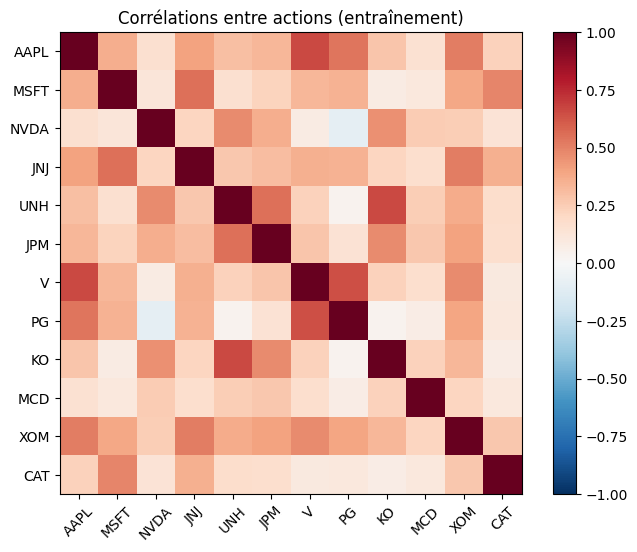

Convergence en 357 itérations — Sharpe = 1.3772


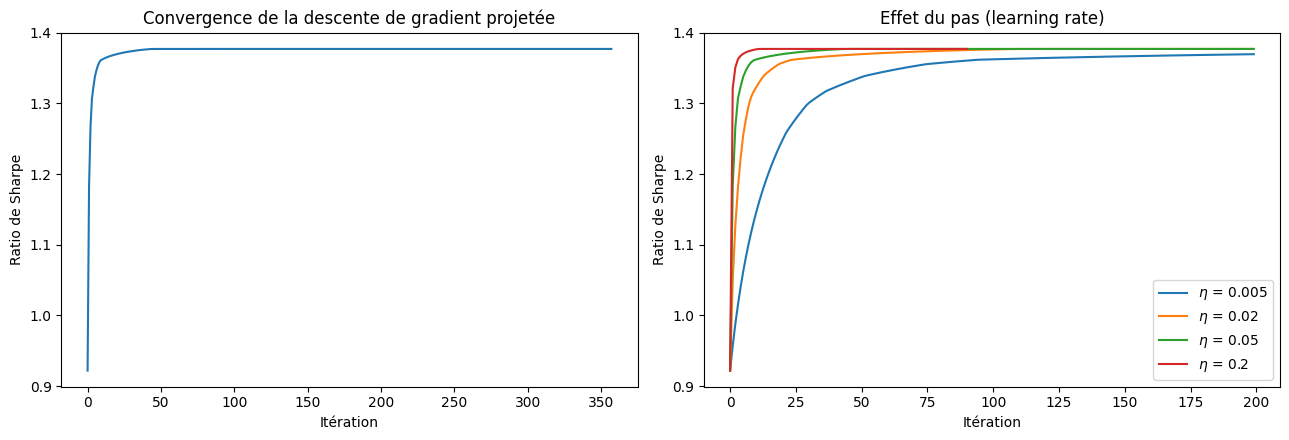

,Sharpe,Temps (s),Écart max sur les poids
Gradient projeté (implémentation maison),1.377233,0.256935,0.000546
SLSQP (scipy),1.377233,0.004763,0.000546


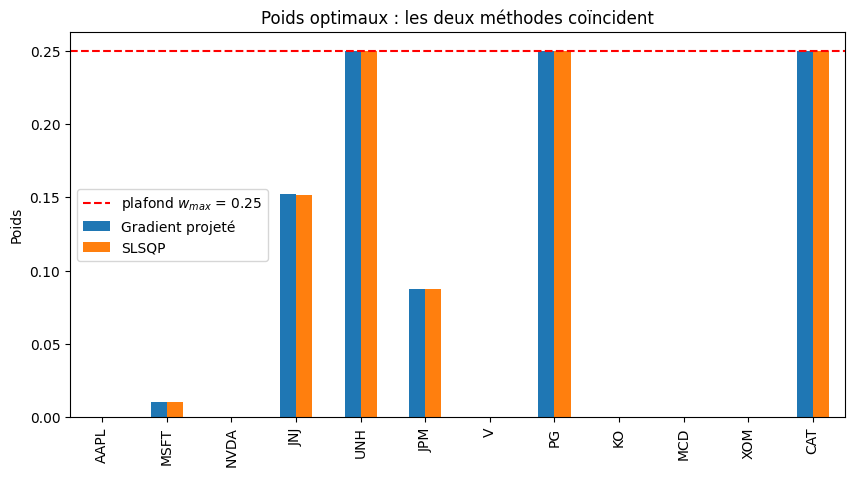

,Optimal — entraînement,Optimal — TEST (hors-échantillon),Équipondéré — TEST
Rendement annualisé,0.3123,0.2360,0.2616
Volatilité annualisée,0.1977,0.1123,0.0947
Sharpe (réalisé),1.3772,1.7453,2.3399
VaR 95 % (jour),0.0182,0.0102,0.0092
CVaR 95 % (jour),0.0265,0.0133,0.0112
Drawdown maximal,0.2190,0.0529,0.0650


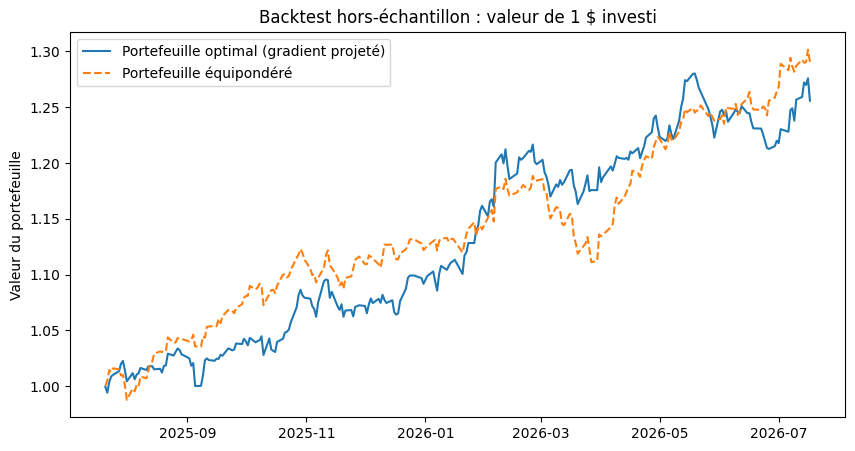

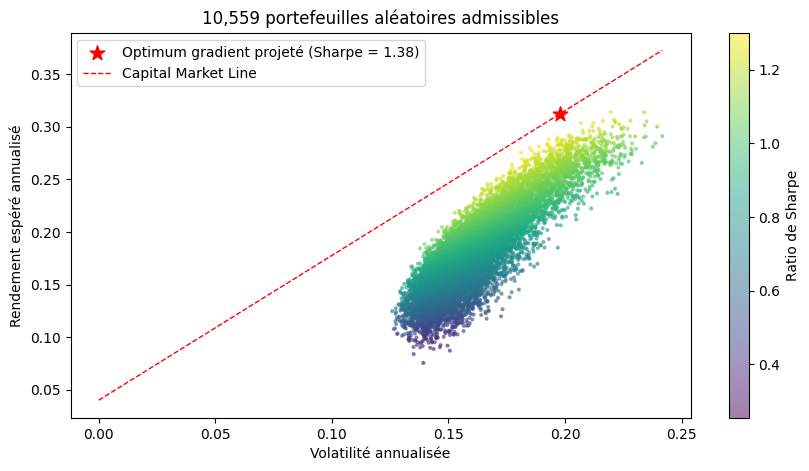

Rendement espéré annualisé : 31.23%
Volatilité annualisée      : 19.77%
Ratio de Sharpe            : 1.377
PG      0.250
CAT     0.250
UNH     0.250
JNJ     0.152
JPM     0.087
MSFT    0.010
dtype: float64


In [ ]:
## with sharpe ratio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)

TICKERS = ["AAPL", "MSFT", "NVDA", "JNJ", "UNH", "JPM",
           "V", "PG", "KO", "MCD", "XOM", "CAT"]

raw = yf.download(TICKERS, period="5y", auto_adjust=True, progress=False)
prices = raw["Close"].dropna(how="any")

# Découpage entraînement / test (hors-échantillon)
split = int(len(prices) * 0.8)
prices_train, prices_test = prices.iloc[:split], prices.iloc[split:]

TRADING_DAYS = 252
returns_train = prices_train.pct_change().dropna()
returns_test  = prices_test.pct_change().dropna()

mu    = returns_train.mean().values * TRADING_DAYS          # rendements espérés annualisés
Sigma = returns_train.cov().values  * TRADING_DAYS          # covariance annualisée
rf    = 0.04                                                # taux sans risque ~ T-bills
n     = len(TICKERS)

stats = pd.DataFrame({"Rendement annualisé": mu,
                      "Volatilité annualisée": np.sqrt(np.diag(Sigma))},
                     index=TICKERS)
display(stats.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(returns_train.corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n), TICKERS, rotation=45); ax.set_yticks(range(n), TICKERS)
fig.colorbar(im); ax.set_title("Corrélations entre actions (entraînement)")
plt.show()


W_MAX = 0.25   # plafond de 25 % par action (contrainte de diversification)

def project(v, w_max=W_MAX):
    """Projection euclidienne sur {w : sum(w)=1, 0 <= w_i <= w_max} (bissection sur tau)."""
    lo, hi = v.min() - 1.0, v.max()
    for _ in range(100):                      # 100 bissections -> précision ~1e-30
        tau = 0.5 * (lo + hi)
        if np.clip(v - tau, 0.0, w_max).sum() > 1.0:
            lo = tau
        else:
            hi = tau
    return np.clip(v - 0.5 * (lo + hi), 0.0, w_max)

def sharpe(w, mu=mu, Sigma=Sigma, rf=rf):
    return (mu @ w - rf) / np.sqrt(w @ Sigma @ w)

def grad_sharpe(w, mu=mu, Sigma=Sigma, rf=rf):
    Sw  = Sigma @ w
    sig = np.sqrt(w @ Sw)
    return mu / sig - (mu @ w - rf) * Sw / sig**3

def projected_gradient_descent(eta=0.05, max_iter=10_000, tol=1e-10, verbose=True):
    """Maximise le ratio de Sharpe par montée de gradient projetée."""
    w = np.full(n, 1.0 / n)                   # point de départ : portefeuille équipondéré
    history = [sharpe(w)]
    for k in range(max_iter):
        w_new = project(w + eta * grad_sharpe(w))
        step  = np.linalg.norm(w_new - w)
        w     = w_new
        history.append(sharpe(w))
        if step < tol:
            break
    if verbose:
        print(f"Convergence en {k+1} itérations — Sharpe = {history[-1]:.4f}")
    return w, np.array(history)

w_gd, history = projected_gradient_descent()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(history)
axes[0].set_xlabel("Itération"); axes[0].set_ylabel("Ratio de Sharpe")
axes[0].set_title("Convergence de la descente de gradient projetée")

for eta in [0.005, 0.02, 0.05, 0.2]:
    _, h = projected_gradient_descent(eta=eta, verbose=False)
    axes[1].plot(h[:200], label=f"$\\eta$ = {eta}")
axes[1].set_xlabel("Itération"); axes[1].set_ylabel("Ratio de Sharpe")
axes[1].set_title("Effet du pas (learning rate)"); axes[1].legend()
plt.tight_layout(); plt.show()


import time

# Descente de gradient projetée (chronométrée)
t0 = time.perf_counter()
w_gd, history = projected_gradient_descent(verbose=False)
t_gd = time.perf_counter() - t0

#  SLSQP
t0 = time.perf_counter()
res = minimize(lambda w: -sharpe(w), np.full(n, 1/n), method="SLSQP",
               jac=lambda w: -grad_sharpe(w),
               bounds=[(0, W_MAX)] * n,
               constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
t_slsqp = time.perf_counter() - t0
w_slsqp = res.x

comp = pd.DataFrame({
    "Sharpe": [sharpe(w_gd), sharpe(w_slsqp)],
    "Temps (s)": [t_gd, t_slsqp],
    "Écart max sur les poids": [np.abs(w_gd - w_slsqp).max()] * 2,
}, index=["Gradient projeté (implémentation maison)", "SLSQP (scipy)"])
display(comp.round(6))

weights = pd.DataFrame({"Gradient projeté": w_gd, "SLSQP": w_slsqp}, index=TICKERS)
weights.plot.bar(title="Poids optimaux : les deux méthodes coïncident")
plt.axhline(W_MAX, ls="--", c="red", label=f"plafond $w_{{max}}$ = {W_MAX}")
plt.ylabel("Poids"); plt.legend(); plt.show()

def risk_report(weights_vec, returns_df, rf=rf, label=""):
    """Métriques de risque calculées sur des rendements journaliers réalisés."""
    port = returns_df.values @ weights_vec               # rendements journaliers du portefeuille
    ann_ret = port.mean() * TRADING_DAYS
    ann_vol = port.std(ddof=1) * np.sqrt(TRADING_DAYS)
    var95  = -np.percentile(port, 5)                     # VaR journalière 95 %
    cvar95 = -port[port <= np.percentile(port, 5)].mean()# CVaR journalière 95 %
    cum = np.cumprod(1 + port)
    max_dd = (1 - cum / np.maximum.accumulate(cum)).max()
    return pd.Series({"Rendement annualisé": ann_ret,
                      "Volatilité annualisée": ann_vol,
                      "Sharpe (réalisé)": (ann_ret - rf) / ann_vol,
                      "VaR 95 % (jour)": var95,
                      "CVaR 95 % (jour)": cvar95,
                      "Drawdown maximal": max_dd}, name=label)

w_eq = np.full(n, 1.0 / n)
report = pd.concat([
    risk_report(w_gd, returns_train, label="Optimal — entraînement"),
    risk_report(w_gd, returns_test,  label="Optimal — TEST (hors-échantillon)"),
    risk_report(w_eq, returns_test,  label="Équipondéré — TEST"),
], axis=1)
display(report.round(4))

# Courbes de richesse cumulée sur la période de test
cum_opt = (1 + returns_test @ w_gd).cumprod()
cum_eq  = (1 + returns_test @ w_eq).cumprod()
plt.plot(cum_opt, label="Portefeuille optimal (gradient projeté)")
plt.plot(cum_eq,  label="Portefeuille équipondéré", ls="--")
plt.title("Backtest hors-échantillon : valeur de 1 $ investi")
plt.ylabel("Valeur du portefeuille"); plt.legend(); plt.show()


M = 20_000
W_rand = np.random.dirichlet(np.ones(n), size=M)
W_rand = W_rand[(W_rand <= W_MAX).all(axis=1)]           # on garde ceux qui respectent le plafond
rets = W_rand @ mu
vols = np.sqrt(np.einsum("ij,jk,ik->i", W_rand, Sigma, W_rand))
sharpes = (rets - rf) / vols

sc = plt.scatter(vols, rets, c=sharpes, cmap="viridis", s=4, alpha=0.5)
plt.colorbar(sc, label="Ratio de Sharpe")
sig_opt = np.sqrt(w_gd @ Sigma @ w_gd)
plt.scatter([sig_opt], [mu @ w_gd], c="red", s=120, marker="*",
            label=f"Optimum gradient projeté (Sharpe = {sharpe(w_gd):.2f})", zorder=5)
x = np.linspace(0, vols.max(), 50)
plt.plot(x, rf + sharpe(w_gd) * x, "r--", lw=1, label="Capital Market Line")
plt.xlabel("Volatilité annualisée"); plt.ylabel("Rendement espéré annualisé")
plt.title(f"{len(W_rand):,} portefeuilles aléatoires admissibles")
plt.legend(); plt.show()

##########################
rendement_optimal = mu @ w_gd                      # rendement espéré annualisé
vol_optimale = np.sqrt(w_gd @ Sigma @ w_gd)        # volatilité annualisée

print(f"Rendement espéré annualisé : {rendement_optimal:.2%}")
print(f"Volatilité annualisée      : {vol_optimale:.2%}")
print(f"Ratio de Sharpe            : {sharpe(w_gd):.3f}")

# Et la composition du portefeuille :
poids = pd.Series(w_gd, index=TICKERS).sort_values(ascending=False)
print(poids[poids > 0.001].round(3))




=== Single Mini-batch Gradient Descent Run ===

Portfolio Weights
JNJ     0.250
PG      0.199
CAT     0.147
MSFT    0.095
NVDA    0.068
JPM     0.063
V       0.053
MCD     0.041
UNH     0.034
KO      0.026
XOM     0.024
dtype: float64

Iterations to convergence: 10000
Utility change over last 200 iterations: 0.00002000


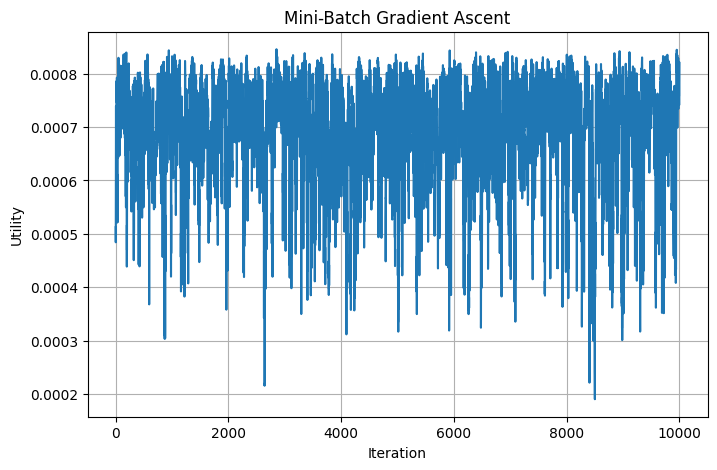


GRID SEARCH
    learning_rate  batch_size  iterations_to_convergence  runtime_seconds  \
0              50          20                     9840.6        10.545719   
1              50          60                     9670.2        10.733996   
2              75          60                     8050.4         8.892133   
3              25          20                    10000.0        11.236142   
4              10          20                    10000.0        11.283107   
5              10          60                    10000.0        11.190425   
6              75          40                     7886.6         8.572889   
7              25          60                    10000.0        10.914003   
8              75          20                     6000.4         6.346956   
9              25          40                    10000.0        10.723617   
10             50          40                    10000.0        10.908531   
11             10          40                    10000.0       

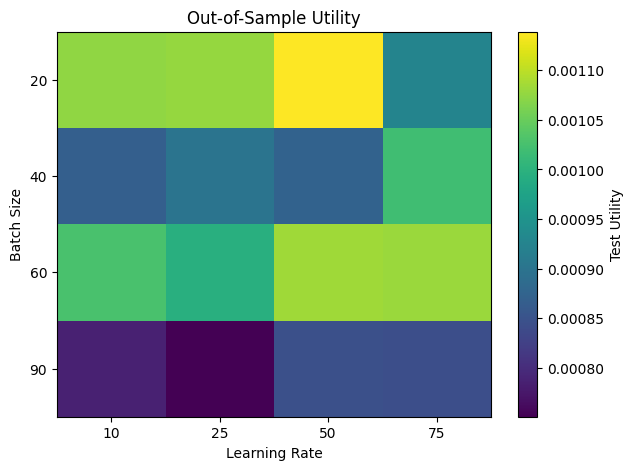


SUMMARY STATISTICS

Number of assets: 12
Training period: 1003 days
Testing period: 250 days
Risk-free rate (annualized): 4.00%
Risk aversion parameter: 5.0
Max weight per asset: 25%


In [ ]:
"""
End-to-end: import data -> mini-batch projected gradient descent
-> grid search over (learning_rate, batch_size), evaluated out-of-sample.

Variable names follow your original notebook's Sharpe-ratio cell
(TICKERS, prices, returns_train/test, mu, Sigma, W_MAX, rf) so you can
drop this straight into the same notebook.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import time

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 5)


# =======================================================================
# 1. IMPORT DATA
# =======================================================================
TICKERS = ["AAPL", "MSFT", "NVDA", "JNJ", "UNH", "JPM",
           "V", "PG", "KO", "MCD", "XOM", "CAT"]

raw = yf.download(TICKERS, period="5y", auto_adjust=True, progress=False)
prices = raw["Close"].dropna(how="any")

# Train / test split (out-of-sample), same 80/20 split as your last cell
split = int(len(prices) * 0.8)
prices_train, prices_test = prices.iloc[:split], prices.iloc[split:]

returns_train = prices_train.pct_change().dropna()
returns_test = prices_test.pct_change().dropna()

n = len(TICKERS)
rf = 0.04          # risk-free rate, annualized (kept from your notebook)
W_MAX = 0.25       # per-asset cap, same as your Sharpe-ratio cell

# Convert to plain numpy arrays for the optimizer (daily, not annualized —
# risk_aversion below is calibrated for DAILY returns; see note at the bottom)
R_train = returns_train.to_numpy()
R_test = returns_test.to_numpy()


# =======================================================================
# 2. CONSTRAINT PROJECTION: sum(w)=1, 0 <= w_i <= W_MAX
#    (identical to your Sharpe-ratio cell's `project`, this part was correct)
# =======================================================================
def project(v, w_max=W_MAX):
    """Euclidean projection onto {w : sum(w)=1, 0 <= w_i <= w_max} via bisection."""
    lo, hi = v.min() - 1.0, v.max()
    for _ in range(100):
        tau = 0.5 * (lo + hi)
        if np.clip(v - tau, 0.0, w_max).sum() > 1.0:
            lo = tau
        else:
            hi = tau
    return np.clip(v - 0.5 * (lo + hi), 0.0, w_max)


# =======================================================================
# 3. OBJECTIVE: maximize  mu.w - (risk_aversion/2) * w' Sigma w
# =======================================================================
def batch_mu_sigma(returns_batch):
    mu_b = returns_batch.mean(axis=0)
    Sigma_b = np.cov(returns_batch, rowvar=False)
    return mu_b, Sigma_b


def utility_grad(w, mu, Sigma, risk_aversion):
    return mu - risk_aversion * (Sigma @ w)


def utility_value(w, mu, Sigma, risk_aversion):
    return mu @ w - 0.5 * risk_aversion * (w @ Sigma @ w)


# =======================================================================
# 4. MINI-BATCH PROJECTED GRADIENT ASCENT
#    Each iteration resamples a random subset of days, estimates mu/Sigma
#    from just that subset, takes a gradient step, then projects.
# =======================================================================
def minibatch_gradient_descent(
    returns,
    risk_aversion=5.0,
    w_max=W_MAX,
    learning_rate=0.05,
    batch_size=40,
    iterations=300,
    tol=1e-9,
    seed=None,
):
    start_time = time.perf_counter()      # <-- ADD

    rng = np.random.default_rng(seed)
    T, n_assets = returns.shape
    w = np.full(n_assets, 1.0 / n_assets)

    utility_history = np.zeros(iterations)
    full_mu, full_Sigma = batch_mu_sigma(returns)

    last_i = iterations - 1

    for i in range(iterations):
        idx = rng.integers(0, T, size=min(batch_size, T))
        batch = returns[idx]
        mu_b, Sigma_b = batch_mu_sigma(batch)

        grad = utility_grad(w, mu_b, Sigma_b, risk_aversion)
        w_new = project(w + learning_rate * grad, w_max)

        step = np.linalg.norm(w_new - w)
        w = w_new
        utility_history[i] = utility_value(w, full_mu, full_Sigma, risk_aversion)

        if step < tol:
            utility_history[i:] = utility_history[i]
            last_i = i
            break

    elapsed = time.perf_counter() - start_time   # <-- ADD

    return {
        "weights": w,
        "utility_history": utility_history,
        "final_utility": utility_history[last_i],
        "iterations_run": last_i + 1,
        "runtime_seconds": elapsed,              # <-- ADD
    }

def minibatch_gradient_descent_shrunk(
    returns,
    risk_aversion=5.0,
    w_max=W_MAX,
    learning_rate=0.05,
    batch_size=40,
    iterations=10000,
    shrink_lambda=0.0,
    tol=1e-9,
    seed=None,
):
    """
    Same as minibatch_gradient_descent, but each step is pulled toward the
    equal-weight portfolio using a PROXIMAL update:
        w_step  = w + lr * grad(mu, Sigma)          # ordinary gradient step
        w_shrunk = w_eq + (w_step - w_eq) / (1 + 2*lr*shrink_lambda)
        w_new    = project(w_shrunk)

    This is the closed-form solution of the shrinkage penalty and is
    UNCONDITIONALLY STABLE for any shrink_lambda >= 0 -- unlike adding
    -2*shrink_lambda*(w - w_eq) directly into the gradient, which is only
    stable when lr*shrink_lambda < 1 and diverges/oscillates above that.
    shrink_lambda=0 exactly reproduces the unregularized case.
    """
    rng = np.random.default_rng(seed)
    T, n_assets = returns.shape
    w = np.full(n_assets, 1.0 / n_assets)
    w_eq = np.full(n_assets, 1.0 / n_assets)

    utility_history = np.zeros(iterations)  # TRUE (unregularized) utility, for honest tracking
    full_mu, full_Sigma = batch_mu_sigma(returns)

    last_i = iterations - 1
    for i in range(iterations):
        idx = rng.integers(0, T, size=min(batch_size, T))
        batch = returns[idx]
        mu_b, Sigma_b = batch_mu_sigma(batch)

        grad = utility_grad(w, mu_b, Sigma_b, risk_aversion)
        w_step = w + learning_rate * grad
        w_shrunk = w_eq + (w_step - w_eq) / (1.0 + 2.0 * learning_rate * shrink_lambda)
        w_new = project(w_shrunk, w_max)

        step = np.linalg.norm(w_new - w)
        w = w_new
        utility_history[i] = utility_value(w, full_mu, full_Sigma, risk_aversion)

        if step < tol:
            utility_history[i:] = utility_history[i]
            last_i = i
            break

    return {
        "weights": w,
        "utility_history": utility_history,
        "final_utility": utility_history[last_i],
        "iterations_run": last_i + 1,
    }


# =======================================================================
# 5. GRID SEARCH over (learning_rate, batch_size), scored OUT-OF-SAMPLE
# =======================================================================
import time

def grid_search(
    returns_train,
    returns_test,
    risk_aversion=2.0,
    w_max=W_MAX,
    learning_rates=(10,25,50,75),
    batch_sizes=(20, 40, 80),
    iterations=10000,
    n_seeds=5,
    base_seed=0,
):
    """
    Grid search over learning rate and batch size.
    Reports:
        - Test utility
        - Annualized return
        - Annualized volatility
        - Average iterations to convergence
        - Average runtime
    """

    results = []
    test_mu, test_Sigma = batch_mu_sigma(returns_test)

    for lr in learning_rates:
        for bs in batch_sizes:

            seed_utilities = []
            seed_returns = []
            seed_vols = []
            seed_iters = []
            seed_times = []

            weight_accum = np.zeros(returns_train.shape[1])

            for s in range(n_seeds):

                # Start timer
                start = time.perf_counter()

                out = minibatch_gradient_descent(
                    returns_train,
                    risk_aversion=risk_aversion,
                    w_max=w_max,
                    learning_rate=lr,
                    batch_size=bs,
                    iterations=iterations,
                    seed=base_seed + s,
                )

                # Stop timer
                elapsed = time.perf_counter() - start

                w = out["weights"]

                seed_utilities.append(
                    utility_value(w, test_mu, test_Sigma, risk_aversion)
                )

                seed_returns.append(test_mu @ w)
                seed_vols.append(np.sqrt(w @ test_Sigma @ w))
                seed_iters.append(out["iterations_run"])
                seed_times.append(elapsed)

                weight_accum += w

            results.append({
                "learning_rate": lr,
                "batch_size": bs,
                "iterations_to_convergence": np.mean(seed_iters),
                "runtime_seconds": np.mean(seed_times),
                "test_utility_mean": np.mean(seed_utilities),
                "test_utility_std": np.std(seed_utilities),
                "test_return_annualized": np.mean(seed_returns) * 252,
                "test_vol_annualized": np.mean(seed_vols) * np.sqrt(252),
                "weights_mean": weight_accum / n_seeds,
            })

    df = (
        pd.DataFrame(results)
        .sort_values("test_utility_mean", ascending=False)
        .reset_index(drop=True)
    )

    return df

# =======================================================================
# 6. RUN IT
# =======================================================================
if __name__ == "__main__":

    RISK_AVERSION = 5.0

    # -------------------------------------------------------------
    # Single Mini-batch Gradient Descent Run
    # -------------------------------------------------------------
    print("=== Single Mini-batch Gradient Descent Run ===")

    out = minibatch_gradient_descent(
        R_train,
        risk_aversion=RISK_AVERSION,
        w_max=W_MAX,
        learning_rate=10,
        batch_size=40,
        iterations=10000,
        seed=1,
    )

    weights = pd.Series(out["weights"], index=TICKERS).sort_values(ascending=False)

    print("\nPortfolio Weights")
    print(weights[weights > 0.001].round(3))

    print(f"\nIterations to convergence: {out['iterations_run']}")

    tail = out["utility_history"][-200:]
    print(f"Utility change over last 200 iterations: {tail[-1]-tail[0]:.8f}")

    plt.figure(figsize=(8,5))
    plt.plot(out["utility_history"][:out["iterations_run"]])
    plt.title("Mini-Batch Gradient Ascent")
    plt.xlabel("Iteration")
    plt.ylabel("Utility")
    plt.grid(True)
    plt.show()


    # -------------------------------------------------------------
    # Grid Search
    # -------------------------------------------------------------
    print("\n===================================================")
    print("GRID SEARCH")
    print("===================================================")

    grid_df = grid_search(
        R_train,
        R_test,
        risk_aversion=RISK_AVERSION,
        w_max=W_MAX,
        learning_rates=(10,25,50,75),
        batch_sizes=(20,40,60,90),
        iterations=10000,
        n_seeds=5,
        base_seed=1
    )

    print(
        grid_df[
            [
                "learning_rate",
                "batch_size",
                "iterations_to_convergence",
                "runtime_seconds",
                "test_utility_mean",
                "test_return_annualized",
                "test_vol_annualized",
            ]
        ].round(6)
    )


    # -------------------------------------------------------------
    # Equal Weight Benchmark
    # -------------------------------------------------------------
    w_eq = np.full(n,1/n)

    test_mu, test_Sigma = batch_mu_sigma(R_test)

    u_eq = utility_value(
        w_eq,
        test_mu,
        test_Sigma,
        RISK_AVERSION,
    )

    print("\nEqual-weight utility:", round(u_eq,6))
    print("Best utility:", round(grid_df.iloc[0]["test_utility_mean"],6))


    # -------------------------------------------------------------
    # Best Portfolio - with Expected Returns
    # -------------------------------------------------------------
    best = grid_df.iloc[0]

    print("\n===============================")
    print("Best Hyperparameters")
    print("===============================")

    print("Learning Rate :", best["learning_rate"])
    print("Batch Size    :", best["batch_size"])
    print("Iterations    :", round(best["iterations_to_convergence"],1))
    print("Runtime (sec) :", round(best["runtime_seconds"],4))
    print("Utility       :", round(best["test_utility_mean"],6))

    best_weights = best["weights_mean"]

    # Calculate expected returns for the best portfolio
    test_mu, test_Sigma = batch_mu_sigma(R_test)
    best_expected_return = test_mu @ best_weights
    best_volatility = np.sqrt(best_weights @ test_Sigma @ best_weights)

    print(f"\nBest Portfolio Expected Daily Return: {best_expected_return:.6f}")
    print(f"Best Portfolio Expected Annualized Return: {best_expected_return * 252:.4f}")
    print(f"Best Portfolio Volatility (daily): {best_volatility:.6f}")
    print(f"Best Portfolio Volatility (annualized): {best_volatility * np.sqrt(252):.4f}")
    print(f"Sharpe Ratio: {(best_expected_return * 252 - rf) / (best_volatility * np.sqrt(252)):.4f}")

    # Individual asset expected returns
    print("\nIndividual Asset Expected Returns (Annualized):")
    expected_returns_df = pd.DataFrame({
        'Ticker': TICKERS,
        'Daily_Return': test_mu,
        'Annualized_Return': test_mu * 252
    })
    print(expected_returns_df.round(6))

    best_weights_series = pd.Series(best_weights, index=TICKERS).sort_values(ascending=False)

    print("\nBest Portfolio Weights")
    print(best_weights_series[best_weights_series > 0.001].round(3))


    # -------------------------------------------------------------
    # Heatmap
    # -------------------------------------------------------------
    pivot = grid_df.pivot(
        index="batch_size",
        columns="learning_rate",
        values="test_utility_mean",
    )

    plt.figure(figsize=(7,5))

    plt.imshow(pivot.values, aspect="auto", cmap="viridis")

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    plt.xlabel("Learning Rate")
    plt.ylabel("Batch Size")
    plt.title("Out-of-Sample Utility")

    plt.colorbar(label="Test Utility")

    plt.show()

    # -------------------------------------------------------------
    # Summary Statistics
    # -------------------------------------------------------------
    print("\n===============================")
    print("SUMMARY STATISTICS")
    print("===============================")

    print(f"\nNumber of assets: {n}")
    print(f"Training period: {len(returns_train)} days")
    print(f"Testing period: {len(returns_test)} days")
    print(f"Risk-free rate (annualized): {rf:.2%}")
    print(f"Risk aversion parameter: {RISK_AVERSION}")
    print(f"Max weight per asset: {W_MAX:.0%}")

# NOTE ON SCALE: R_train/R_test here are DAILY returns, so mu and Sigma
# are daily-scale too. RISK_AVERSION=5.0 is calibrated for that scale.
# If you'd rather work in annualized terms (mu*252, Sigma*252, like your
# original cell), rescale R_train/R_test accordingly BEFORE calling
# minibatch_gradient_descent, and re-tune risk_aversion -- mixing daily
# mu with an annualized risk_aversion silently breaks the tradeoff.